In [4]:
import os
import clip
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm

In [5]:
device = 'cuda:5'
clip_model, clip_processor = clip.load("ViT-B/32", device)

In [6]:
def encode_image(image):
    image_input = clip_processor(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
    return image_features

In [7]:
ori_root = '/amax/hchuz/Image-to-Graph/dataset/original'
res_root = '/amax/hchuz/architectural_heritage/results/imgs_eval_200'
res_root_2 = '/amax/hchuz/architectural_heritage/results/imgs_eval_200_focus'
res_root_3 = '/amax/hchuz/architectural_heritage/results/imgs_eval_200_size'

In [8]:
ori_feats = []
for it in tqdm(os.listdir(ori_root)):
    if not it.endswith('.png'):
        continue
    ori_feats.append(encode_image(Image.open(os.path.join(ori_root, it))))
ori_feats = torch.cat(ori_feats)

100%|██████████| 385/385 [00:07<00:00, 52.97it/s]


In [9]:
res_feats = []
for it in tqdm(os.listdir(res_root)):
    if not it.endswith('.png'):
        continue
    if 'control' in it:
        continue
    res_feats.append(encode_image(Image.open(os.path.join(res_root, it))))
res_feats = torch.cat(res_feats)

100%|██████████| 961/961 [01:10<00:00, 13.58it/s]


In [10]:
res_feats_2 = []
for it in tqdm(os.listdir(res_root_2)):
    if not it.endswith('.png'):
        continue
    if 'control' in it:
        continue
    res_feats_2.append(encode_image(Image.open(os.path.join(res_root_2, it))))
res_feats_2 = torch.cat(res_feats_2)

100%|██████████| 961/961 [00:30<00:00, 31.04it/s]


In [11]:
res_feats_3 = []
for it in tqdm(os.listdir(res_root_3)):
    if not it.endswith('.png'):
        continue
    if 'control' in it:
        continue
    res_feats_3.append(encode_image(Image.open(os.path.join(res_root_3, it))))
res_feats_3 = torch.cat(res_feats_3)

100%|██████████| 960/960 [00:49<00:00, 19.29it/s]


In [14]:
X = torch.cat([ori_feats, res_feats_2, res_feats_3]).cpu()
y = torch.cat([torch.zeros(len(ori_feats)), torch.ones(len(res_feats_2)) * 2, torch.ones(len(res_feats_3)) * 3  ])

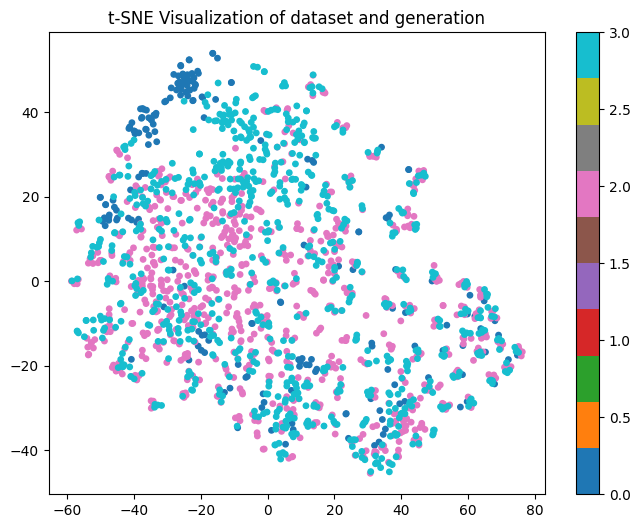

In [15]:
# 使用 t-SNE 降维到 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X)

# 可视化结果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15)
plt.colorbar(scatter)
plt.title('t-SNE Visualization of dataset and generation')
plt.show()